In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
from pathlib import Path
import pickle
import os
import dask.dataframe as dd
from sklearn.model_selection import train_test_split
import warnings
import math
from collections import defaultdict
from tqdm import tqdm

import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)
from torch.utils.data import Dataset, DataLoader

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

2.10.0
0.22.1


In [2]:
# Caricamento dati

file_path_z = "data/ZJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS54000001.parquet"
file_path_w = "data/WJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS45000001.parquet"
parameters = [
    # Jets
    "FullReco_JetAK4_PT",
    "FullReco_JetAK4_Eta",
    "FullReco_JetAK4_Phi",
    "FullReco_JetAK4_Mass",
    "FullReco_JetAK4_Charge",
    "FullReco_JetAK4_Constituents",

    #Contituents
    "FullReco_PFCand_PT",
    "FullReco_PFCand_Eta",
    "FullReco_PFCand_Phi",
    "FullReco_PFCand_PID",
    "FullReco_PFCand_Charge",
    "FullReco_PFCand_Mass",
    "FullReco_PFCand_D0",
    "FullReco_PFCand_DZ",
    "FullReco_PFCand_ErrorD0",
    "FullReco_PFCand_ErrorDZ",
    "FullReco_PFCand_fUniqueID",
    "FullReco_PFCand_PuppiW"
]

ddf_z = dd.read_parquet(file_path_z, parameters)
ddf_w = dd.read_parquet(file_path_w, parameters)

In [3]:
warnings.filterwarnings('ignore')

# Parametri essenziali per costituente (14 features totali)
CONSTITUENT_FEATURES = [
    'log1p_pt',         # 0: log(1+pt)
    'delta_eta',        # 1: η - η_jet
    'delta_phi',        # 2: φ - φ_jet (periodico)
    'charge',           # 3: carica
    'log1p_mass',       # 4: log(1+ massa)
    'd0_norm',          # 5: d0/σ_d0
    'dz_norm',          # 6: dz/σ_dz
    'log1p_d0_err',     # 7: log(1+σ_d0)
    'log1p_dz_err',     # 8: log(1+σ_dz)
    'puppiW',           # 9: peso pileup
    'is_charged',       # 10: 1 se carica ≠ 0
    'is_pion',          # 11: 1 se |PID| == 45
    'is_kaon',          # 12: 1 se |PID| == 65
    'is_proton',        # 13: 1 se |PID| == 92
]

# PID da escludere
EXCLUDE_PID = {22}  # fotoni

def safe_log1p(x):
    """log(1+x) - sempre positivo, stabile per x=0"""
    return np.log1p(max(abs(x), 0))

def prepare_jet_dataset(ddf, min_jet_pt=50, max_constituents=60, min_constituents=3, n_partitions=None):
    """
    Prepara dataset jet+constituents per foundation model.
    """
    def process_partition(partition):
        examples = []
        
        for _, row in partition.iterrows():
            # --- Estrazione dati con fallback safe ---
            def safe_arr(key, default=np.array([])):
                val = row.get(key)
                if val is None:
                    return default
                return np.asarray(val).flatten()
            
            jet_pt = safe_arr('FullReco_JetAK4_PT')
            jet_eta = safe_arr('FullReco_JetAK4_Eta')
            jet_phi = safe_arr('FullReco_JetAK4_Phi')
            jet_mass = safe_arr('FullReco_JetAK4_Mass')
            jet_charge = safe_arr('FullReco_JetAK4_Charge', np.zeros_like(jet_pt))  # aggiunto
            jet_constituents = row.get('FullReco_JetAK4_Constituents', [])
            
            pf_pt = safe_arr('FullReco_PFCand_PT')
            pf_eta = safe_arr('FullReco_PFCand_Eta')
            pf_phi = safe_arr('FullReco_PFCand_Phi')
            pf_mass = safe_arr('FullReco_PFCand_Mass')
            pf_charge = safe_arr('FullReco_PFCand_Charge')
            pf_pid = safe_arr('FullReco_PFCand_PID')
            pf_d0 = safe_arr('FullReco_PFCand_D0')
            pf_dz = safe_arr('FullReco_PFCand_DZ')
            pf_d0_err = safe_arr('FullReco_PFCand_ErrorD0', np.ones_like(pf_pt))
            pf_dz_err = safe_arr('FullReco_PFCand_ErrorDZ', np.ones_like(pf_pt))
            pf_puppi = safe_arr('FullReco_PFCand_PuppiW', np.ones_like(pf_pt))
            pf_id = safe_arr('FullReco_PFCand_fUniqueID')
            
            if len(jet_pt) == 0 or len(pf_pt) == 0:
                continue
            
            # Mappa ID -> indice
            id_to_idx = {int(id_val): i for i, id_val in enumerate(pf_id) if id_val is not None}
            
            # Processa ogni jet
            for j in range(len(jet_pt)):
                # Tagli base
                if jet_pt[j] < min_jet_pt or jet_mass[j] <= 0:
                    continue
                
                if j >= len(jet_constituents):
                    continue
                
                # Ottieni IDs dei costituenti
                const_ids = jet_constituents[j]
                if const_ids is None:
                    continue
                const_ids = np.atleast_1d(const_ids).flatten()
                
                # Estrai features costituenti
                features = []
                for cid in const_ids:
                    try:
                        idx = id_to_idx.get(int(cid))
                        if idx is None or idx >= len(pf_pid):
                            continue
                        
                        pid = abs(int(pf_pid[idx]))
                        if pid in EXCLUDE_PID:
                            continue
                        
                        # Calcola features con safe_log1p
                        log1p_pt = safe_log1p(pf_pt[idx])
                        delta_eta = pf_eta[idx] - jet_eta[j]
                        delta_phi = ((pf_phi[idx] - jet_phi[j] + np.pi) % (2*np.pi)) - np.pi
                        log1p_mass = safe_log1p(pf_mass[idx])
                        
                        d0_norm = pf_d0[idx] #/ max(pf_d0_err[idx], 1e-8)      momentaneamente no normalizzazione con errore
                        dz_norm = pf_dz[idx] #/ max(pf_dz_err[idx], 1e-8)
                        log1p_d0_err = safe_log1p(pf_d0_err[idx])
                        log1p_dz_err = safe_log1p(pf_dz_err[idx])
                        
                        features.append([
                            log1p_pt, delta_eta, delta_phi,
                            pf_charge[idx], log1p_mass,
                            d0_norm, dz_norm,
                            log1p_d0_err, log1p_dz_err,
                            pf_puppi[idx],
                            1.0 if pf_charge[idx] != 0 else 0.0,
                            1.0 if pid == 45 else 0.0,
                            1.0 if pid == 65 else 0.0,
                            1.0 if pid == 92 else 0.0,
                        ])
                    except (ValueError, TypeError, IndexError):
                        continue
                
                if len(features) < min_constituents:
                    continue
                
                # Estrai pt da log1p_pt (indice 0) e ordina
                pt_values = np.array([f[0] for f in features])  # log1p_pt
                sort_indices = np.argsort(pt_values)[::-1]  # Ordine decrescente
                features_sorted = [features[i] for i in sort_indices]
                
                # Padding/truncation DOPO l'ordinamento
                features_sorted = np.array(features_sorted[:max_constituents], dtype=np.float32)
                if len(features_sorted) < max_constituents:
                    pad = np.zeros((max_constituents - len(features_sorted), features_sorted.shape[1]), dtype=np.float32)
                    features_sorted = np.vstack([features_sorted, pad])
                
                # Jet features (6 features: pt, eta, phi, mass, charge)
                jet_feats = np.array([
                    safe_log1p(jet_pt[j]),      # log1p(pt)
                    jet_eta[j],                  # eta
                    np.sin(jet_phi[j]),          # sin(phi)
                    np.cos(jet_phi[j]),          # cos(phi)
                    safe_log1p(jet_mass[j]),     # log1p(mass)
                    jet_charge[j] if j < len(jet_charge) else 0.0,  # charge
                ], dtype=np.float32)
                
                examples.append({
                    'jet': jet_feats,
                    'const': features_sorted,
                    'n_const': min(len(features), max_constituents)
                })
        
        return pd.DataFrame(examples) if examples else pd.DataFrame(columns=['jet', 'const', 'n_const'])
    
    # Definisci metadata
    meta = pd.DataFrame(columns=['jet', 'const', 'n_const']).astype({
        'jet': 'object', 
        'const': 'object', 
        'n_const': 'int64'
    })
    
    # Applica con o senza partizioni
    if n_partitions is not None:
        partitions_to_process = ddf.partitions[:n_partitions]
        result = partitions_to_process.map_partitions(process_partition, meta=meta).compute()
    else:
        result = ddf.map_partitions(process_partition, meta=meta).compute()
    
    return result


class JetDataset(Dataset):
    """Dataset PyTorch compatto"""
    def __init__(self, df, class_mapping=None):
        self.df = df.reset_index(drop=True)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        result = {
            'jet': torch.tensor(row['jet'], dtype=torch.float32),
            'const': torch.tensor(row['const'], dtype=torch.float32),
            'n_const': torch.tensor(row['n_const'], dtype=torch.long),
        }
        
        return result

In [4]:
# Prepara dataset
n_partitions = 100

print("Preparazione dataset Z...")
z_data = prepare_jet_dataset(ddf_z, min_jet_pt=50, max_constituents=60, 
                             min_constituents=3, n_partitions=n_partitions)

print("Preparazione dataset W...")
w_data = prepare_jet_dataset(ddf_w, min_jet_pt=50, max_constituents=60, 
                             min_constituents=3, n_partitions=n_partitions)

# Combina
combined = pd.concat([z_data, w_data], ignore_index=True)
print(f"\nTotale jet: {len(combined)}")
print(f"Feature cost: {combined['const'].iloc[0].shape[1]} features")
print(f"Feature jet: {combined['jet'].iloc[0].shape[0]} features")

# Dataset e DataLoader
dataset = JetDataset(combined)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

# Verifica sample
sample = next(iter(loader))
print(f"\nBatch shapes:")
print(f"  Jet features: {sample['jet'].shape}")  # [batch, 4]
print(f"  Const features: {sample['const'].shape}")  # [batch, max_const, 14]
print(f"  N constituents: {sample['n_const'].shape}")  # [batch]

# Verifica statistiche PID
const_data = sample['const']
print(f"\nStatistiche PID:")
print(f"  Pion: {(const_data[:,:,11] > 0).float().mean():.2%}")
print(f"  Kaon: {(const_data[:,:,12] > 0).float().mean():.2%}")
print(f"  Proton: {(const_data[:,:,13] > 0).float().mean():.2%}")
print(f"  Charged: {(const_data[:,:,10] > 0).float().mean():.2%}")

Preparazione dataset Z...
Preparazione dataset W...

Totale jet: 10127
Feature cost: 14 features
Feature jet: 6 features

Batch shapes:
  Jet features: torch.Size([32, 6])
  Const features: torch.Size([32, 60, 14])
  N constituents: torch.Size([32])

Statistiche PID:
  Pion: 9.32%
  Kaon: 1.46%
  Proton: 0.89%
  Charged: 11.98%


In [5]:
class Normalizer:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, x):
        self.mean = x.mean(axis=0)
        self.std = x.std(axis=0) + 1e-8

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse_transform(self, x):
        return x * self.std + self.mean

In [6]:
# ===== NORMALIZATION =====

const_features = np.stack(combined['const'].values)   # (N, 60, F)
jet_features = np.stack(combined['jet'].values)       # (N, F)

n_const = combined['n_const'].values

# mask per ignorare padding
mask = np.arange(const_features.shape[1])[None, :] < n_const[:, None]
valid_const = const_features[mask]

# crea normalizzatori
const_norm = Normalizer()
jet_norm = Normalizer()

# fit SOLO sui dati validi
const_continous_idx = [0,1,2,4,5,6,7,8]
jet_continous_idx = [0,1,2,3,4]
const_norm.fit(valid_const[:, const_continous_idx])
jet_norm.fit(jet_features[:, jet_continous_idx])

# Salvataggio parametri di normalizzazione
os.makedirs("./results", exist_ok=True)

with open("./results/const_norm.pkl", "wb") as f:
    pickle.dump(const_norm, f)

with open("./results/jet_norm.pkl", "wb") as f:
    pickle.dump(jet_norm, f)

# applica
const_features[:, :, const_continous_idx] = const_norm.transform(const_features[:, :, const_continous_idx])
jet_features[:, jet_continous_idx] = jet_norm.transform(jet_features[:, jet_continous_idx])

# rimetti nel dataframe
combined['const'] = list(const_features)
combined['jet'] = list(jet_features)

In [7]:
# Crea il dataloader
dataset = JetDataset(combined)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

# Estrai un batch
batch = next(iter(loader))

print("=== BATCH INFO ===")
print(f"Batch size: {batch['jet'].shape[0]}")
print(f"Jet features shape: {batch['jet'].shape}")  # [batch, 6]
print(f"Const features shape: {batch['const'].shape}")  # [batch, max_const, 14]
print(f"N constituents: {batch['n_const'].shape}")  # [batch]

# Ispeziona il primo evento del batch
event_idx = 0
print(f"\n=== EVENTO {event_idx} ===")

# Jet features
jet = batch['jet'][event_idx]
print(f"\nJet features:")
print(f"  log1p_pt: {jet[0]:.2f} -> pt: {np.expm1(jet[0]):.2f} GeV")
print(f"  eta: {jet[1]:.2f}")
print(f"  sin(phi): {jet[2]:.2f} -> phi: {np.arcsin(jet[2]):.2f} rad")
print(f"  cos(phi): {jet[3]:.2f}")
print(f"  log1p_mass: {jet[4]:.2f} -> mass: {np.expm1(jet[4]):.2f} GeV")
print(f"  charge: {jet[5]:.0f}")

# Constituents
n_const = batch['n_const'][event_idx].item()
const = batch['const'][event_idx][:n_const]  # solo i costituenti reali (no padding)

print(f"\nConstituents: {n_const} reali (su {batch['const'].shape[1]} totali)")

# Mostra primi 5 costituenti
print(f"\nPrimi 5 costituenti:")
print(f"{'Idx':<4} {'log1p_pt':<10} {'Δη':<8} {'Δφ':<8} {'charge':<6} {'log1p_mass':<10} {'puppiW':<8} {'type':<10}")
print("-" * 80)

for i in range(min(5, n_const)):
    c = const[i]
    # Determina il tipo di particella
    if c[11] > 0:  # is_pion
        ptype = "pion"
    elif c[12] > 0:  # is_kaon
        ptype = "kaon"
    elif c[13] > 0:  # is_proton
        ptype = "proton"
    elif c[10] > 0:  # is_charged
        ptype = "charged"
    else:
        ptype = "neutral"
    
    print(f"{i:<4} {c[0]:<10.2f} {c[1]:<8.2f} {c[2]:<8.2f} {c[3]:<6.0f} {c[4]:<10.2f} {c[9]:<8.2f} {ptype:<10}")

=== BATCH INFO ===
Batch size: 32
Jet features shape: torch.Size([32, 6])
Const features shape: torch.Size([32, 60, 14])
N constituents: torch.Size([32])

=== EVENTO 0 ===

Jet features:
  log1p_pt: 0.75 -> pt: 1.12 GeV
  eta: 0.48
  sin(phi): -1.25 -> phi: nan rad
  cos(phi): -0.64
  log1p_mass: -0.11 -> mass: -0.10 GeV
  charge: -1

Constituents: 15 reali (su 60 totali)

Primi 5 costituenti:
Idx  log1p_pt   Δη       Δφ       charge log1p_mass puppiW   type      
--------------------------------------------------------------------------------
0    2.69       -0.08    -0.02    -1     0.42       1.00     pion      
1    1.88       -0.12    -0.03    -1     0.42       1.00     pion      
2    1.86       -0.09    -0.19    1      0.42       1.00     pion      
3    1.48       -0.35    -0.16    1      2.43       1.00     kaon      
4    1.40       -0.02    -0.21    1      0.42       1.00     pion      


In [8]:
class LocalAttention(nn.Module):
    """Local attention basata su kNN in Δη-Δφ per i costituenti"""
    def __init__(self, d_model, n_neighbors=32, n_heads=8):
        super().__init__()
        self.d_model = d_model
        self.n_neighbors = n_neighbors
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, x, eta_phi, mask=None):
        """
        x: [batch, n_const, d_model]
        eta_phi: [batch, n_const, 2] (Δη, Δφ)
        mask: [batch, n_const] padding mask (True per posizioni valide)
        """
        batch, n_const, _ = x.shape
        
        # Calcola q, k, v
        qkv = self.qkv(x).reshape(batch, n_const, 3, self.n_heads, self.head_dim)
        q, k, v = qkv.unbind(2)  # [batch, n_const, n_heads, head_dim]
        
        # Calcola le attenzioni standard
        # q: [batch, n_const, n_heads, head_dim]
        # k: [batch, n_const, n_heads, head_dim]
        # Dobbiamo trasporre per fare il prodotto: [batch, n_heads, n_const, n_const]
        q = q.transpose(1, 2)  # [batch, n_heads, n_const, head_dim]
        k = k.transpose(1, 2)  # [batch, n_heads, n_const, head_dim]
        v = v.transpose(1, 2)  # [batch, n_heads, n_const, head_dim]
        
        attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # [batch, n_heads, n_const, n_const]
        
        # Calcola distanze in spazio η-φ per la maschera kNN
        dist = torch.cdist(eta_phi, eta_phi, p=2)  # [batch, n_const, n_const]
        
        # Escludi il punto stesso
        eye = torch.eye(n_const, device=eta_phi.device).unsqueeze(0)
        dist = dist + eye * 1e9
        
        # Seleziona i k vicini più prossimi
        k_neighbors = min(self.n_neighbors, n_const - 1)
        _, neighbor_indices = torch.topk(-dist, k=k_neighbors, dim=-1)  # [batch, n_const, k]
        
        # Crea una maschera densa dai vicini selezionati
        knn_mask = torch.zeros(batch, n_const, n_const, dtype=torch.bool, device=eta_phi.device)
        
        # Riempi la maschera per ogni elemento del batch
        for b in range(batch):
            for i in range(n_const):
                knn_mask[b, i, neighbor_indices[b, i]] = True
        
        # Aggiungi il punto stesso
        knn_mask = knn_mask | torch.eye(n_const, device=eta_phi.device).unsqueeze(0).bool()
        
        # =========================================================
        # CORREZIONE: Espandi la maschera per le testine
        # knn_mask: [batch, n_const, n_const] -> [batch, 1, n_const, n_const]
        # =========================================================
        knn_mask_expanded = knn_mask.unsqueeze(1)  # [batch, 1, n_const, n_const]
        
        # Applica la maschera kNN (espandi automaticamente alle testine)
        attn = attn.masked_fill(~knn_mask_expanded, float('-inf'))
        
        # Applica mask di padding se necessario
        if mask is not None:
            # Estendi la padding mask per l'attenzione
            # mask: [batch, n_const] -> [batch, 1, n_const, n_const]
            padding_mask = mask.unsqueeze(1).unsqueeze(2) & mask.unsqueeze(1).unsqueeze(3)
            attn = attn.masked_fill(~padding_mask, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        
        # Dropout opzionale
        # attn = F.dropout(attn, p=0.1, training=self.training)
        
        out = torch.matmul(attn, v)  # [batch, n_heads, n_const, head_dim]
        out = out.transpose(1, 2).reshape(batch, n_const, self.d_model)
        
        return self.out_proj(out)

class PerceiverCore(nn.Module):
    """Perceiver-style core con latents"""
    def __init__(self, d_model=128, n_latents=64, n_layers=4, n_heads=8):
        super().__init__()
        
        # Latent array learnable
        self.latents = nn.Parameter(torch.randn(1, n_latents, d_model))
        
        # Cross-attention: latents attend to tokens
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model)
        
        # Self-attention layers for latents
        self.self_attn_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model*4, 
                                       dropout=0.1, batch_first=True)
            for _ in range(n_layers)
        ])
        
        # Output projection
        self.out_norm = nn.LayerNorm(d_model)
        
    def forward(self, tokens, mask=None):
        """
        tokens: [batch, n_tokens, d_model]
        """
        batch = tokens.shape[0]
        
        # Expand latents per batch
        latents = self.latents.expand(batch, -1, -1)
        
        # Cross-attention: latents attend to tokens
        latents_out, _ = self.cross_attn(latents, tokens, tokens, key_padding_mask=mask)
        latents = self.cross_norm(latents + latents_out)
        
        # Self-attention on latents
        for layer in self.self_attn_layers:
            latents = layer(latents)
        
        return self.out_norm(latents)


class ConstituentEncoder(nn.Module):
    """Encoder per i costituenti con local mixing kNN"""
    def __init__(self, input_dim=14, d_model=128, n_heads=8, n_neighbors=32):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        
        # Local attention blocks con kNN
        self.local_attention = LocalAttention(d_model, n_neighbors=n_neighbors, n_heads=n_heads)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm3 = nn.LayerNorm(d_model)
        
    def forward(self, x, eta_phi, mask=None):
        # Input projection
        x = self.input_proj(x)
        x = self.norm1(x)
        
        # Local attention con kNN
        attn_out = self.local_attention(x, eta_phi, mask)
        x = x + attn_out
        x = self.norm2(x)
        
        # FFN
        ffn_out = self.ffn(x)
        x = x + ffn_out
        x = self.norm3(x)
        
        return x

class JetEncoder(nn.Module):
    """Encoder per i jet"""
    def __init__(self, input_dim=6, d_model=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model)
        )
    
    def forward(self, x):
        return self.encoder(x)

class JetFoundationModel(nn.Module):
    """Foundation model per jet con kNN attention"""
    def __init__(self, const_input_dim=14, jet_input_dim=6, 
                 d_model=128, n_latents=64, n_heads=8, n_neighbors=32):
        super().__init__()
        
        # Encoders
        self.const_encoder = ConstituentEncoder(
            const_input_dim, d_model, n_heads, n_neighbors
        )
        self.jet_encoder = JetEncoder(jet_input_dim, d_model)
        
        # Perceiver core
        self.perceiver = PerceiverCore(d_model, n_latents, n_layers=4, n_heads=n_heads)
        
        # Heads per pre-training
        self.masked_pf_head = nn.Linear(d_model, const_input_dim)
        self.pu_head = nn.Linear(d_model, 1)
        self.jet_reco_head = nn.Linear(d_model, jet_input_dim)
        
    def forward(self, jet, const, boson_idx=None, const_eta_phi=None, mask=None):
        """
        jet: [batch, 6] - jet features
        const: [batch, max_const, 14] - constituent features
        """
        batch = jet.shape[0]
        
        # Encode constituents
        if const_eta_phi is None:
            # Usa delta_eta e delta_phi come coordinate per local attention
            const_eta_phi = const[:, :, 1:3]  # [batch, n_const, 2]
        
        const_emb = self.const_encoder(const, const_eta_phi, mask)
        
        # Encode jet
        jet_emb = self.jet_encoder(jet)        
        jet_emb = jet_emb.unsqueeze(1)  # [batch, 1, d_model]
        
        # Combina tokens
        all_tokens = torch.cat([jet_emb, const_emb], dim=1)
        
        # Create mask for padding
        if mask is not None:
            jet_mask = torch.ones(batch, 1, device=mask.device, dtype=mask.dtype)
            full_mask = torch.cat([jet_mask, mask], dim=1)
        else:
            full_mask = None
        
        # Perceiver core
        latents = self.perceiver(all_tokens, full_mask)
        
        # Heads
        global_rep = latents[:, 0, :]
        
        pf_reconstruction = self.masked_pf_head(const_emb)
        pu_pred = self.pu_head(const_emb).squeeze(-1)
        jet_reco = self.jet_reco_head(global_rep)
        
        return {
            'pf_reconstruction': pf_reconstruction,
            'pu_prediction': pu_pred,
            'jet_reconstruction': jet_reco,
            'latents': latents
        }

In [9]:
class PretrainingLosses(nn.Module):
    """Loss per gli obiettivi di pre-training - versione semplificata"""
    
    def __init__(self, mask_ratio=0.15):
        super().__init__()
        self.mask_ratio = mask_ratio
        
    def forward(self, model_output, batch, model):
        """
        Calcola le loss per il pre-training
        """
        const = batch['const']
        jet = batch['jet']
        n_const = batch['n_const']
        device = const.device
        
        # Mask per padding
        mask = torch.arange(const.shape[1], device=device).unsqueeze(0) < n_const.unsqueeze(1)
        
        # 1. Masked PF modeling (loss A)
        # Crea mask casuale per i costituenti
        random_mask = torch.rand(const.shape[0], const.shape[1], device=device) < self.mask_ratio
        random_mask = random_mask & mask
        
        # Azzera tutte le feature delle particelle mascherate
        const_masked = const.clone()
        const_masked[random_mask] = 0.0  

        outputs = model(
            jet=jet,
            const=const_masked,  
            const_eta_phi=None,
            mask=mask
        )
        
        # Loss di ricostruzione solo sulle posizioni mascherate
        pf_reconstruction = model_output['pf_reconstruction']
        mse_loss = F.mse_loss(pf_reconstruction[random_mask], const[random_mask])
        
        # 2. PU prediction (loss B)
        # Target: puppiW < 0.5 indica pileup
        isPU_target = (const[:, :, 9] < 0.5).float()
        pu_loss = F.binary_cross_entropy_with_logits(model_output['pu_prediction'], isPU_target)
        
        # 3. Jet reconstruction (parte della loss C)
        jet_target = jet[:, :]  # log1p_pt, eta, sin(phi), cos(phi), mass, charge
        jet_loss = F.mse_loss(model_output['jet_reconstruction'], jet_target)

        # Loss totale con nuovo peso
        total_loss = (mse_loss * 1.0 + pu_loss * 0.5 + jet_loss * 0.3)
        
        return {
            'total': total_loss,
            'masked_pf': mse_loss,
            'pu': pu_loss,
            'jet_reco': jet_loss
        }

In [10]:
def train_model_with_logging(model, dataloader, epochs=10, lr=1e-4, device='cuda', 
                             val_dataloader=None, save_every=5):
    """
    Training loop con logging delle loss e salvataggio checkpoint
    """
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = PretrainingLosses(mask_ratio=0.15)
    
    # Logging
    history = {
        'train_loss': defaultdict(list),
        'val_loss': defaultdict(list),
        'lr': []
    }
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = defaultdict(float)
        
        progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        
        for batch in progress_bar:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(
                jet=batch['jet'],
                const=batch['const'],
                const_eta_phi=None,
                mask=None
            )
            
            losses = criterion(outputs, batch, model)
            
            optimizer.zero_grad()
            losses['total'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            for key in losses:
                train_losses[key] += losses[key].item()
            
            progress_bar.set_postfix({
                'loss': losses['total'].item(),
                'pf': losses['masked_pf'].item(),
                'pu': losses['pu'].item()
            })
        
        # Media delle loss
        n_batches = len(dataloader)
        for key in train_losses:
            history['train_loss'][key].append(train_losses[key] / n_batches)
        
        # Validation
        if val_dataloader is not None:
            model.eval()
            val_losses = defaultdict(float)
            with torch.no_grad():
                for batch in val_dataloader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    outputs = model(
                        jet=batch['jet'],
                        const=batch['const'],
                        const_eta_phi=None,
                        mask=None
                    )
                    losses = criterion(outputs, batch, model)
                    for key in losses:
                        val_losses[key] += losses[key].item()
            
            n_val = len(val_dataloader)
            for key in val_losses:
                history['val_loss'][key].append(val_losses[key] / n_val)
        
        scheduler.step()
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # Report
        print(f"\nEpoch {epoch+1}:")
        print(f"  Train Loss: {history['train_loss']['total'][-1]:.4f}")
        print(f"    - Masked PF: {history['train_loss']['masked_pf'][-1]:.4f}")
        print(f"    - PU: {history['train_loss']['pu'][-1]:.4f}")
        print(f"    - Jet Reco: {history['train_loss']['jet_reco'][-1]:.4f}")
        if val_dataloader is not None:
            print(f"  Val Loss: {history['val_loss']['total'][-1]:.4f}")
        
        # Salva checkpoint
        if (epoch + 1) % save_every == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history
            }, f'checkpoint_epoch_{epoch+1}.pth')
    
    return model, history

In [11]:
def plot_training_history(history, save_path=None):
    """
    Plotta le loss durante il training
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(history['train_loss']['total']) + 1)
    
    # 1. Total Loss
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss']['total'], 'b-', label='Train', linewidth=2)
    if 'val_loss' in history and history['val_loss']['total']:
        ax.plot(epochs, history['val_loss']['total'], 'r-', label='Validation', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Individual Losses
    ax = axes[0, 1]
    for key in ['masked_pf', 'pu', 'jet_reco']:
        if key in history['train_loss']:
            ax.plot(epochs, history['train_loss'][key], label=key, linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Individual Training Losses')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # 3. Learning Rate
    ax = axes[1, 0]
    ax.plot(epochs, history['lr'], 'g-', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule')
    ax.grid(True, alpha=0.3)
    
    # 4. Validation Loss (se disponibile)
    ax = axes[1, 1]
    if 'val_loss' in history and history['val_loss']['total']:
        for key in ['total', 'masked_pf', 'pu', 'jet_reco']:
            if key in history['val_loss'] and history['val_loss'][key]:
                ax.plot(epochs, history['val_loss'][key], label=key, linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Validation Losses')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No validation data', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Validation Losses')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [12]:
def evaluate_model(model, dataloader, device='cuda', max_batches=None):
    """
    Valuta il modello su un dataloader
    """
    model.eval()
    
    metrics = {
        'mse_pf': [],
        'mse_jet': [],
        'pu_accuracy': [],
        'pu_auc': []
    }
    
    all_pu_preds = []
    all_pu_targets = []
    
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
            if max_batches and i >= max_batches:
                break
                
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                jet=batch['jet'],
                const=batch['const'],
                const_eta_phi=None,
                mask=None
            )
            
            # MSE per PF ricostruzione (solo costituenti reali)
            n_const = batch['n_const']
            mask = torch.arange(batch['const'].shape[1], device=device).unsqueeze(0) < n_const.unsqueeze(1)
            
            pf_mse = F.mse_loss(outputs['pf_reconstruction'][mask], 
                               batch['const'][mask]).item()
            metrics['mse_pf'].append(pf_mse)
            
            # MSE per jet ricostruzione
            jet_target = batch['jet'][:, :]
            jet_mse = F.mse_loss(outputs['jet_reconstruction'], jet_target).item()
            metrics['mse_jet'].append(jet_mse)
            
            # PU prediction accuracy
            pu_pred = torch.sigmoid(outputs['pu_prediction'])
            pu_target = (batch['const'][:, :, 9] < 0.5).float()
            all_pu_preds.append(pu_pred[mask].cpu())
            all_pu_targets.append(pu_target[mask].cpu())
    
    # Calcola metriche aggregate
    results = {
        'mse_pf': np.mean(metrics['mse_pf']),
        'mse_pf_std': np.std(metrics['mse_pf']),
        'mse_jet': np.mean(metrics['mse_jet']),
        'mse_jet_std': np.std(metrics['mse_jet'])
    }
    
    # Calcola accuracy e AUC per PU
    all_pu_preds = torch.cat(all_pu_preds).numpy()
    all_pu_targets = torch.cat(all_pu_targets).numpy()
    
    results['pu_accuracy'] = ((all_pu_preds > 0.5) == all_pu_targets).mean()
    
    from sklearn.metrics import roc_auc_score
    results['pu_auc'] = roc_auc_score(all_pu_targets, all_pu_preds)
    
    return results

def print_evaluation_results(results):
    """Stampa i risultati della valutazione"""
    print("\n" + "="*50)
    print("MODEL EVALUATION RESULTS")
    print("="*50)
    print(f"\nPF Reconstruction:")
    print(f"  MSE: {results['mse_pf']:.6f} ± {results['mse_pf_std']:.6f}")
    
    print(f"\nJet Reconstruction:")
    print(f"  MSE: {results['mse_jet']:.6f} ± {results['mse_jet_std']:.6f}")
    
    print(f"\nPU Prediction:")
    print(f"  Accuracy: {results['pu_accuracy']:.4f}")
    print(f"  AUC: {results['pu_auc']:.4f}")
    print("="*50)

In [13]:
def visualize_reconstruction(model, batch, const_norm, jet_norm, const_continous_idx, jet_continous_idx, device='cuda', save_path=None):
    """
    Visualizza la ricostruzione di un singolo evento
    """
    model.eval()
    batch = {k: v.to(device) for k, v in batch.items()}
    
    with torch.no_grad():
        outputs = model(
            jet=batch['jet'],
            const=batch['const'],
            const_eta_phi=None,
            mask=None
        )
    
    # Prendi il primo evento
    event_idx = 0
    n_const = batch['n_const'][event_idx].item()
    
    # ===== DENORMALIZZAZIONE =====

    const_original = batch['const'][event_idx][:n_const].cpu().numpy()
    const_reconstructed = outputs['pf_reconstruction'][event_idx][:n_const].cpu().numpy()
    
    # denormalizza SOLO i valid constituents
    const_original[:, const_continous_idx] = const_norm.inverse_transform(const_original[:, const_continous_idx])
    const_reconstructed[:, const_continous_idx] = const_norm.inverse_transform(const_reconstructed[:, const_continous_idx])
    
    jet_original = batch['jet'][event_idx][:].cpu().numpy()
    jet_reconstructed = outputs['jet_reconstruction'][event_idx].cpu().numpy()
    
    jet_original[jet_continous_idx] = jet_norm.inverse_transform(jet_original[jet_continous_idx])
    jet_reconstructed[jet_continous_idx] = jet_norm.inverse_transform(jet_reconstructed[jet_continous_idx])
    
    # 1. Plot: PT comparison
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # PT comparison
    ax = axes[0, 0]
    pt_orig = np.expm1(const_original[:, 0])
    pt_recon = np.expm1(const_reconstructed[:, 0])
    ax.scatter(pt_orig, pt_recon, alpha=0.5, s=10)
    ax.plot([pt_orig.min(), pt_orig.max()], [pt_orig.min(), pt_orig.max()], 'r--', label='Perfect')
    ax.set_xlabel('Original PT (GeV)')
    ax.set_ylabel('Reconstructed PT (GeV)')
    ax.set_title('Constituent PT Reconstruction')
    ax.legend()
    
    # Delta Eta comparison
    ax = axes[0, 1]
    ax.scatter(const_original[:, 1], const_reconstructed[:, 1], alpha=0.5, s=10)
    ax.plot([-3, 3], [-3, 3], 'r--')
    ax.set_xlabel('Original Δη')
    ax.set_ylabel('Reconstructed Δη')
    ax.set_title('Δη Reconstruction')
    
    # Delta Phi comparison
    ax = axes[0, 2]
    ax.scatter(const_original[:, 2], const_reconstructed[:, 2], alpha=0.5, s=10)
    ax.plot([-3, 3], [-3, 3], 'r--')
    ax.set_xlabel('Original Δφ')
    ax.set_ylabel('Reconstructed Δφ')
    ax.set_title('Δφ Reconstruction')
    
    # PU Prediction
    ax = axes[1, 0]
    pu_pred = torch.sigmoid(outputs['pu_prediction'][event_idx][:n_const]).cpu().numpy()
    pu_true = (const_original[:, 9] < 0.5).astype(float)
    
    # Plot solo per i costituenti reali
    indices = np.arange(len(pu_true))
    width = 0.35
    ax.bar(indices - width/2, pu_true, width, label='True', alpha=0.7)
    ax.bar(indices + width/2, pu_pred, width, label='Predicted', alpha=0.7)
    ax.set_xlabel('Constituent Index')
    ax.set_ylabel('Is PU')
    ax.set_title('PU Prediction per Constituent')
    ax.legend()
    
    # Jet Reconstruction
    ax = axes[1, 1]
    jet_features = ['log1p_pt', 'eta', 'sin(phi)', 'cos(phi)', 'log1p_mass', 'charge']
    l = len(jet_features)
    x = np.arange(len(jet_features))
    width = 0.35
    ax.bar(x - width/2, jet_original[:l], width, label='Original', alpha=0.7)
    ax.bar(x + width/2, jet_reconstructed[:l], width, label='Reconstructed', alpha=0.7)
    ax.set_xlabel('Jet Features')
    ax.set_ylabel('Value')
    ax.set_title('Jet Reconstruction')
    ax.set_xticks(x)
    ax.set_xticklabels(jet_features, rotation=45)
    ax.legend()
    
    # Error distribution
    ax = axes[1, 2]
    errors = const_reconstructed - const_original
    error_norms = np.linalg.norm(errors, axis=1)
    ax.hist(error_norms, bins=30, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Reconstruction Error (L2 norm)')
    ax.set_ylabel('Frequency')
    ax.set_title('Error Distribution per Constituent')
    ax.axvline(error_norms.mean(), color='r', linestyle='--', label=f'Mean: {error_norms.mean():.3f}')
    ax.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Stampa metriche per questo evento
    print(f"\nEvent {event_idx} Reconstruction Metrics:")
    print(f"  PF MSE: {np.mean(errors**2):.6f}")
    print(f"  Jet MSE: {np.mean((jet_reconstructed - jet_original)**2):.6f}")
    print(f"  PU Accuracy: {np.mean((pu_pred > 0.5) == pu_true):.4f}")
    
    return {
        'pf_mse': np.mean(errors**2),
        'jet_mse': np.mean((jet_reconstructed - jet_original)**2),
        'pu_accuracy': np.mean((pu_pred > 0.5) == pu_true)
    }

In [14]:
def run_training_and_evaluation(model, train_loader, val_loader, 
                                const_norm, jet_norm,
                                const_continous_idx, jet_continous_idx,
                                epochs=10, device='cuda', save_dir='./results'):
    """
    Esegue training, valutazione e visualizzazione
    """
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. Training
    print("="*50)
    print("STARTING TRAINING")
    print("="*50)
    trained_model, history = train_model_with_logging(
        model, train_loader, epochs=epochs, device=device,
        val_dataloader=val_loader, save_every=5
    )
    
    # 2. Plot training history
    print("\n" + "="*50)
    print("PLOTTING TRAINING HISTORY")
    print("="*50)
    plot_training_history(history, save_path=f"{save_dir}/training_history.png")
    
    # 3. Evaluate on validation set
    print("\n" + "="*50)
    print("EVALUATING MODEL")
    print("="*50)
    results = evaluate_model(trained_model, val_loader, device, max_batches=50)
    print_evaluation_results(results)
    
    # 4. Visualize reconstruction
    print("\n" + "="*50)
    print("VISUALIZING RECONSTRUCTION")
    print("="*50)
    val_batch = next(iter(val_loader))
    metrics = visualize_reconstruction(
        trained_model, val_batch,
        const_norm, jet_norm,
        const_continous_idx, jet_continous_idx,
        device=device,
        save_path=f"{save_dir}/reconstruction_example.png"
    )
    
    # 5. Save results
    import json
    with open(f"{save_dir}/eval_results.json", 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\nResults saved to {save_dir}/")
    
    return trained_model, history, results

In [15]:
def print_model_summary(model, input_shapes=None, device='cpu'):
    """
    Stampa un summary dettagliato del modello PyTorch senza librerie esterne.
    
    Args:
        model: Modello PyTorch
        input_shapes: Lista di tuple con le shape degli input (es. [(1,6), (1,60,14)])
        device: Device per il forward pass
    """
    model = model.to(device)
    model.eval()
    
    print("\n" + "="*80)
    print(f"MODEL SUMMARY: {model.__class__.__name__}")
    print("="*80)
    
    # Conta parametri per modulo
    total_params = 0
    trainable_params = 0
    
    print(f"\n{'MODULE':<40} {'TYPE':<30} {'PARAMS':>12} {'TRAINABLE':>12}")
    print("-"*80)
    
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # Solo moduli foglia
            num_params = sum(p.numel() for p in module.parameters())
            num_trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
            
            if num_params > 0:
                total_params += num_params
                trainable_params += num_trainable
                
                # Mostra modulo
                module_name = name if name else 'root'
                print(f"{module_name:<40} {module.__class__.__name__:<30} {num_params:>12,} {num_trainable:>12,}")
    
    print("-"*80)
    print(f"{'TOTAL':<40} {'':<30} {total_params:>12,} {trainable_params:>12,}")
    print("="*80)
    
    # Memoria
    param_memory = total_params * 4 / 1024 / 1024  # float32 = 4 bytes
    print(f"\n📊 Memory (float32): {param_memory:.2f} MB")
    
    # Forward pass per vedere le shape degli output
    if input_shapes is not None:
        print(f"\n📊 FORWARD PASS SHAPES:")
        print("-"*80)
        
        with torch.no_grad():
            # Crea input dummy
            inputs = []
            for shape in input_shapes:
                inputs.append(torch.randn(shape).to(device))
            
            # Forward pass
            outputs = model(*inputs)
            
            # Mostra shape degli input
            for i, inp in enumerate(inputs):
                print(f"  Input {i}: {tuple(inp.shape)}")
            
            # Mostra shape degli output
            if isinstance(outputs, dict):
                for key, value in outputs.items():
                    if isinstance(value, torch.Tensor):
                        print(f"  Output '{key}': {tuple(value.shape)}")
            elif isinstance(outputs, (list, tuple)):
                for i, out in enumerate(outputs):
                    if isinstance(out, torch.Tensor):
                        print(f"  Output {i}: {tuple(out.shape)}")
            else:
                print(f"  Output: {tuple(outputs.shape)}")
        
        print("="*80)
    
    return total_params, trainable_params

In [16]:
# Split indices
train_idx, val_idx = train_test_split(range(len(combined)), test_size=0.2, random_state=42)

# Create datasets
train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Create model
model = JetFoundationModel(
    const_input_dim=14, 
    jet_input_dim=6,
    d_model=128, #128
    n_latents=64, #64
    n_heads=8,
    n_neighbors=16 #16
)

# summary() non funziona bene con input multipli, quindi usa invece:
def model_summary(model, input_shapes):
    print(f"\n{'='*80}")
    print(f"MODEL ARCHITECTURE SUMMARY")
    print(f"{'='*80}")
    
    total_params = 0
    trainable_params = 0
    
    for name, param in model.named_parameters():
        num_params = param.numel()
        total_params += num_params
        if param.requires_grad:
            trainable_params += num_params
        print(f"{name:<50} {str(list(param.shape)):<20} {num_params:>10,} params")
    
    print(f"\n{'-'*80}")
    print(f"Total parameters:     {total_params:>10,}")
    print(f"Trainable parameters: {trainable_params:>10,}")
    print(f"Non-trainable params: {total_params - trainable_params:>10,}")
    print(f"{'='*80}")

# Summary modello
total, trainable = print_model_summary(
    model, 
    input_shapes=[(1, 6), (1, 60, 14)],  # batch_size=1
    device='cuda'
)


MODEL SUMMARY: JetFoundationModel

MODULE                                   TYPE                                 PARAMS    TRAINABLE
--------------------------------------------------------------------------------
const_encoder.input_proj                 Linear                                1,920        1,920
const_encoder.norm1                      LayerNorm                               256          256
const_encoder.local_attention.qkv        Linear                               49,536       49,536
const_encoder.local_attention.out_proj   Linear                               16,512       16,512
const_encoder.norm2                      LayerNorm                               256          256
const_encoder.ffn.0                      Linear                               66,048       66,048
const_encoder.ffn.2                      Linear                               65,664       65,664
const_encoder.norm3                      LayerNorm                               256          256
j

STARTING TRAINING


Epoch 1/6: 100%|██████████| 254/254 [00:49<00:00,  5.13it/s, loss=0.0188, pf=0.00822, pu=0.00623]



Epoch 1:
  Train Loss: 0.3106
    - Masked PF: 0.1644
    - PU: 0.0963
    - Jet Reco: 0.3268
  Val Loss: 0.0653


Epoch 2/6: 100%|██████████| 254/254 [00:48<00:00,  5.24it/s, loss=0.00547, pf=0.00128, pu=0.00174]



Epoch 2:
  Train Loss: 0.0501
    - Masked PF: 0.0408
    - PU: 0.0040
    - Jet Reco: 0.0245
  Val Loss: 0.0371


...


Epoch 4:
  Train Loss: 0.0367
    - Masked PF: 0.0324
    - PU: 0.0017
    - Jet Reco: 0.0112
  Val Loss: 0.0270


Epoch 5/6: 100%|██████████| 254/254 [00:51<00:00,  4.91it/s, loss=0.00876, pf=0.00527, pu=0.00201]  



Epoch 5:
  Train Loss: 0.0299
    - Masked PF: 0.0264
    - PU: 0.0015
    - Jet Reco: 0.0094
  Val Loss: 0.0378


Epoch 6/6: 100%|██████████| 254/254 [00:50<00:00,  5.02it/s, loss=0.0046, pf=0.000882, pu=0.00348]  



Epoch 6:
  Train Loss: 0.0283
    - Masked PF: 0.0250
    - PU: 0.0014
    - Jet Reco: 0.0087
  Val Loss: 0.2120

PLOTTING TRAINING HISTORY


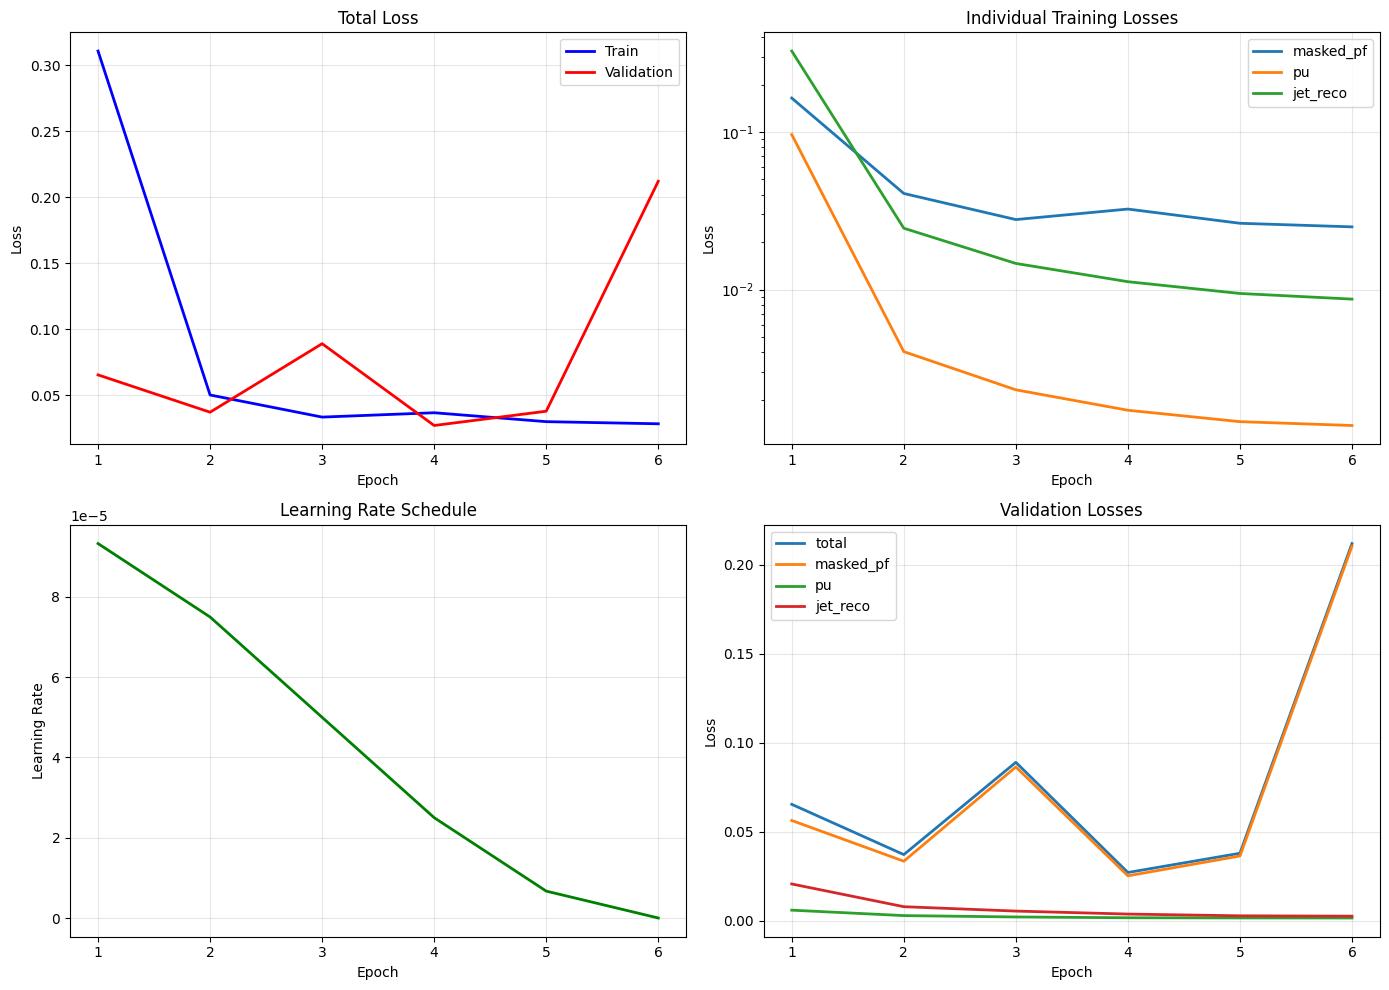


EVALUATING MODEL


Evaluating:  78%|███████▊  | 50/64 [00:04<00:01, 10.67it/s]


MODEL EVALUATION RESULTS

PF Reconstruction:
  MSE: 0.065311 ± 0.157705

Jet Reconstruction:
  MSE: 0.002237 ± 0.001622

PU Prediction:
  Accuracy: 0.9992
  AUC: nan

VISUALIZING RECONSTRUCTION


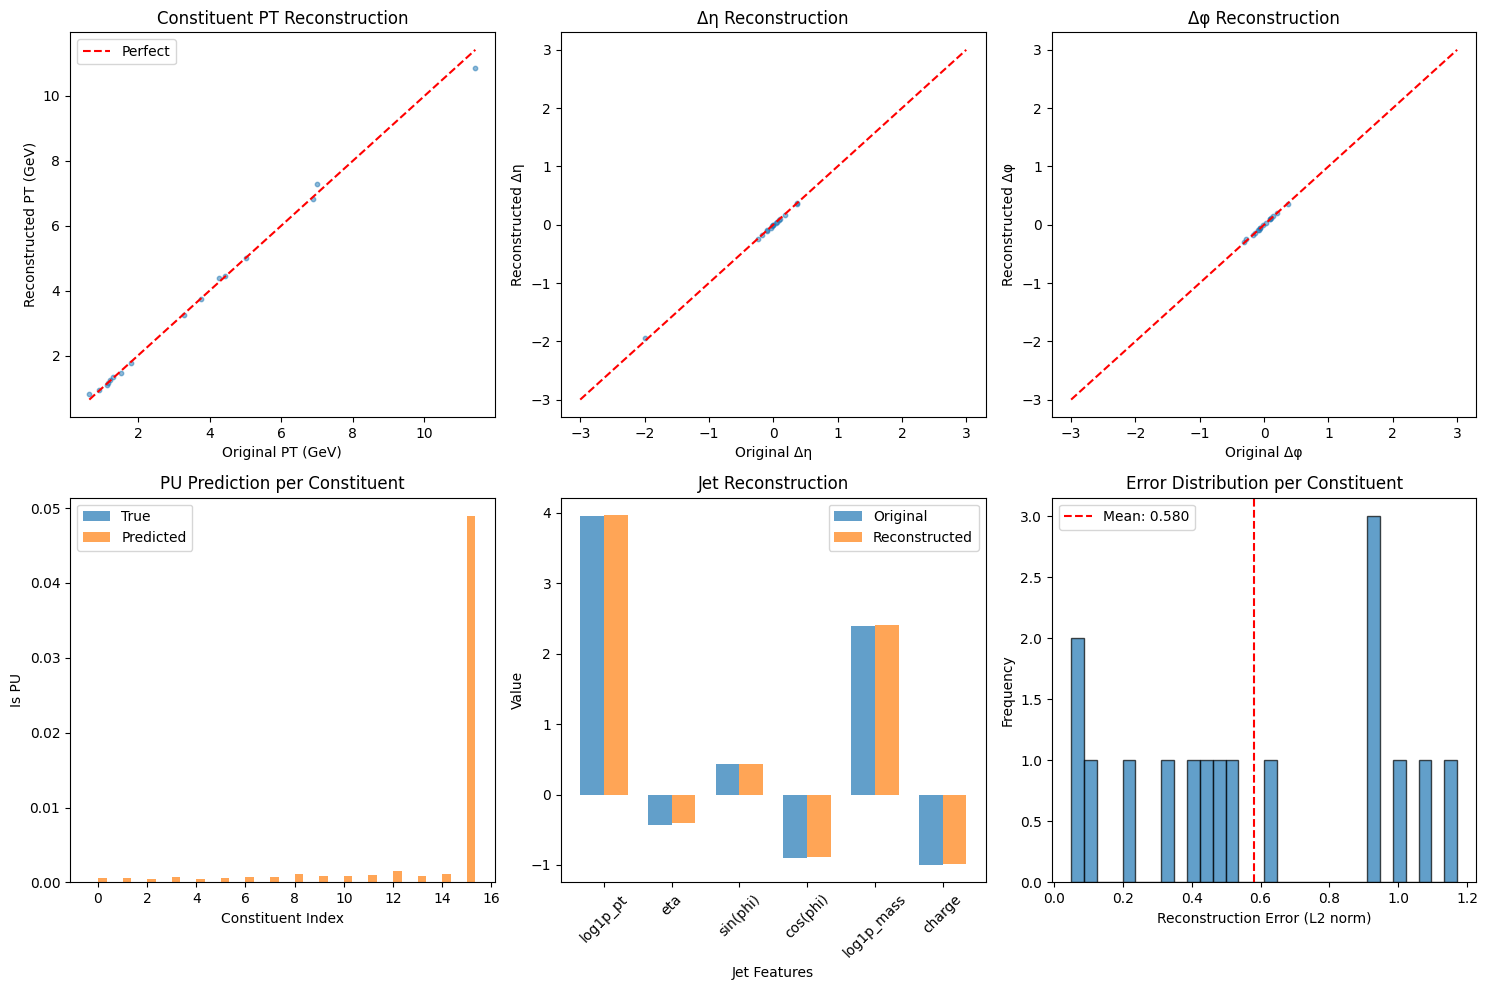


Event 0 Reconstruction Metrics:
  PF MSE: 0.033491
  Jet MSE: 0.000284
  PU Accuracy: 1.0000

Results saved to ./results/


In [17]:
# Run training and evaluation
trained_model, history, results = run_training_and_evaluation(
    model,
    train_loader, val_loader,
    const_norm, jet_norm,
    const_continous_idx, jet_continous_idx,
    epochs=6,
    device='cuda',
    save_dir='./results'
)

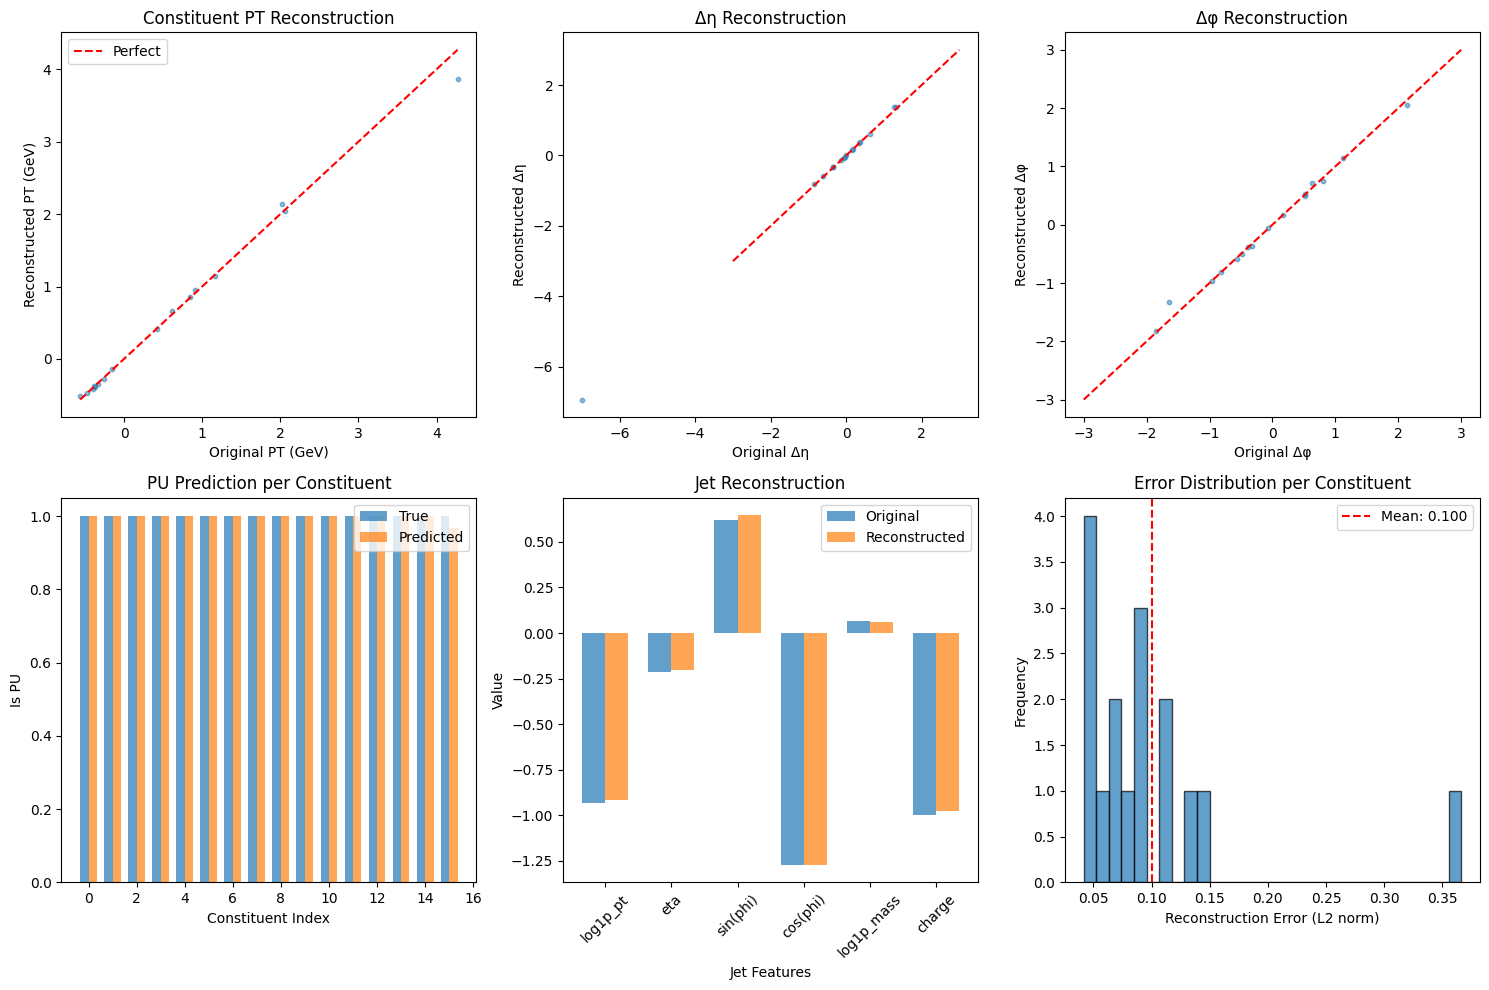


Event 0 Reconstruction Metrics:
  PF MSE: 0.001122
  Jet MSE: 0.000281
  PU Accuracy: 1.0000


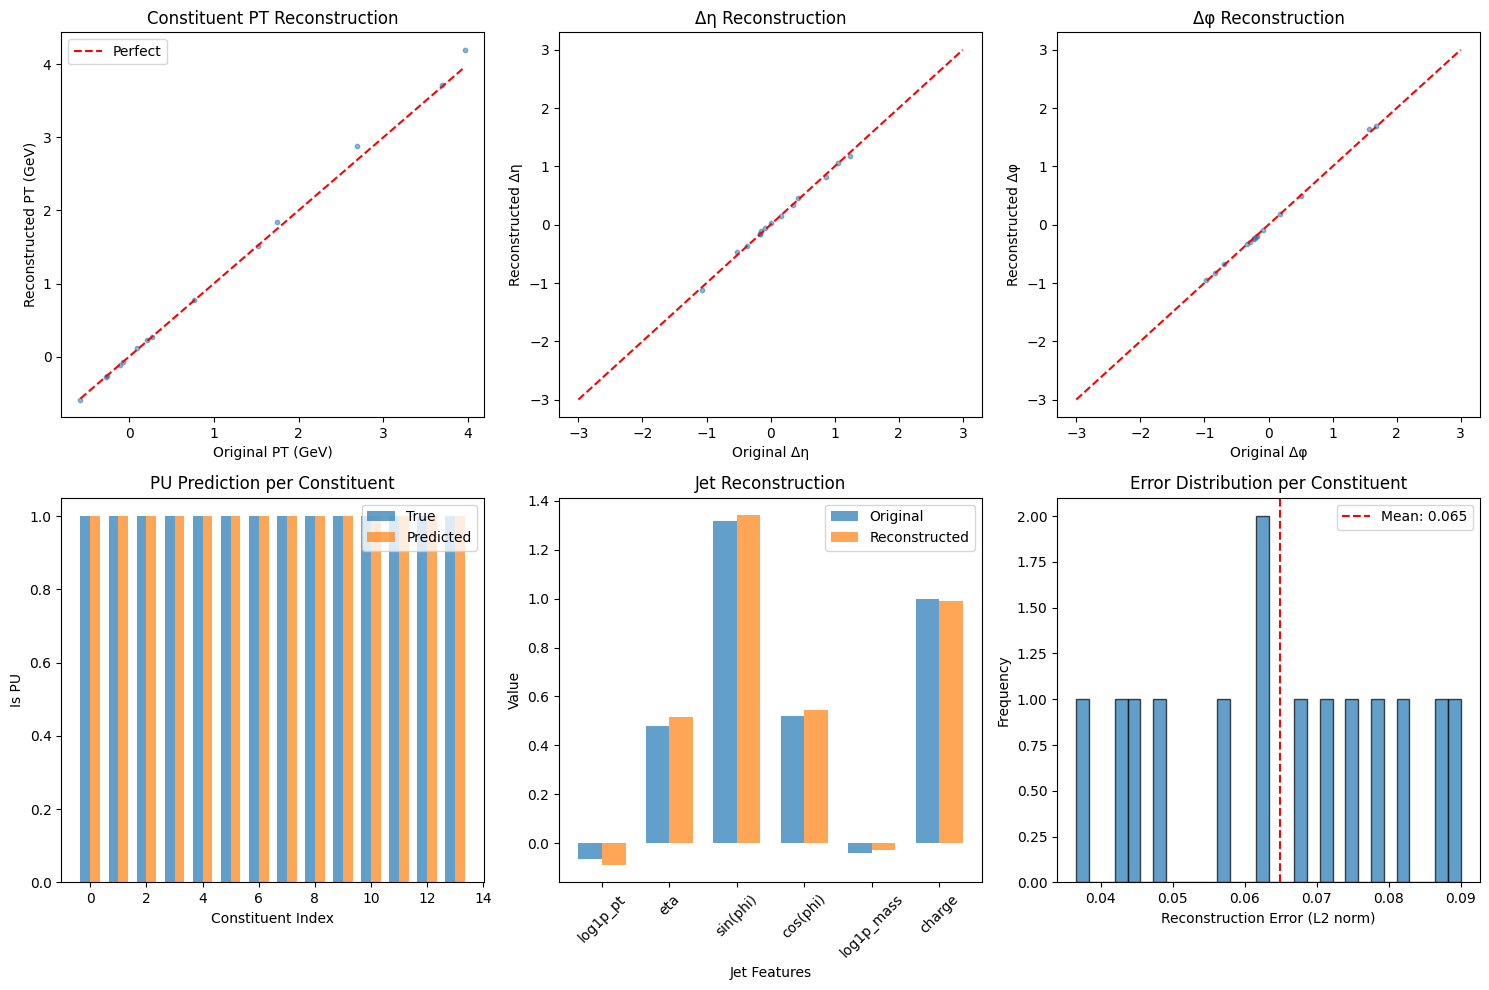


Event 0 Reconstruction Metrics:
  PF MSE: 0.000319
  Jet MSE: 0.000559
  PU Accuracy: 1.0000


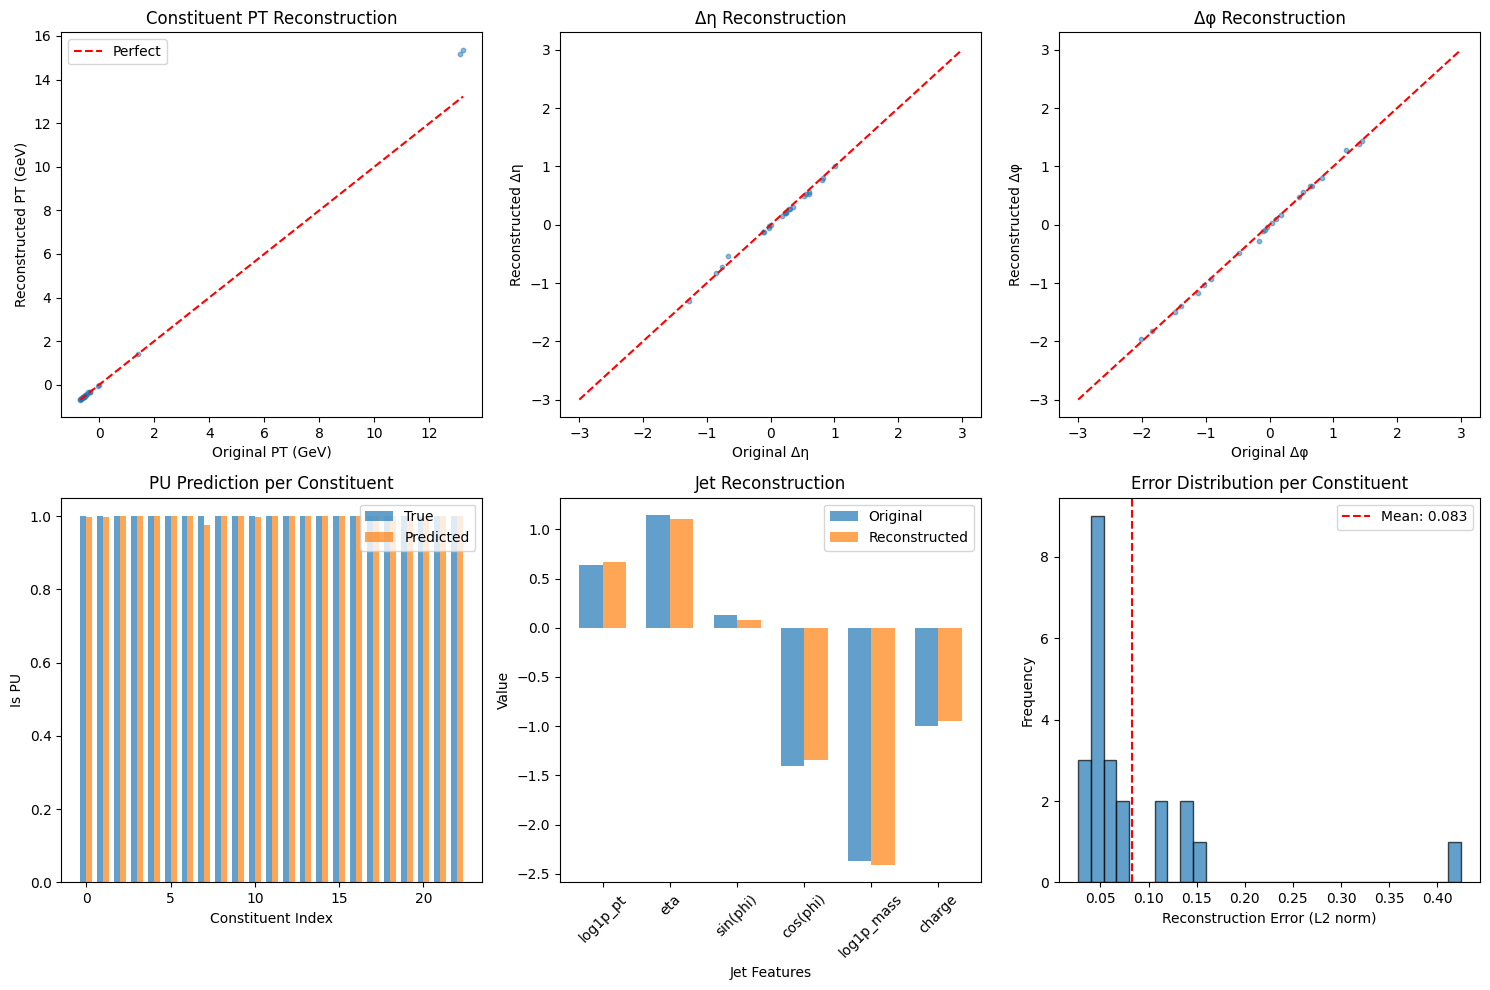


Event 0 Reconstruction Metrics:
  PF MSE: 0.000960
  Jet MSE: 0.002315
  PU Accuracy: 1.0000


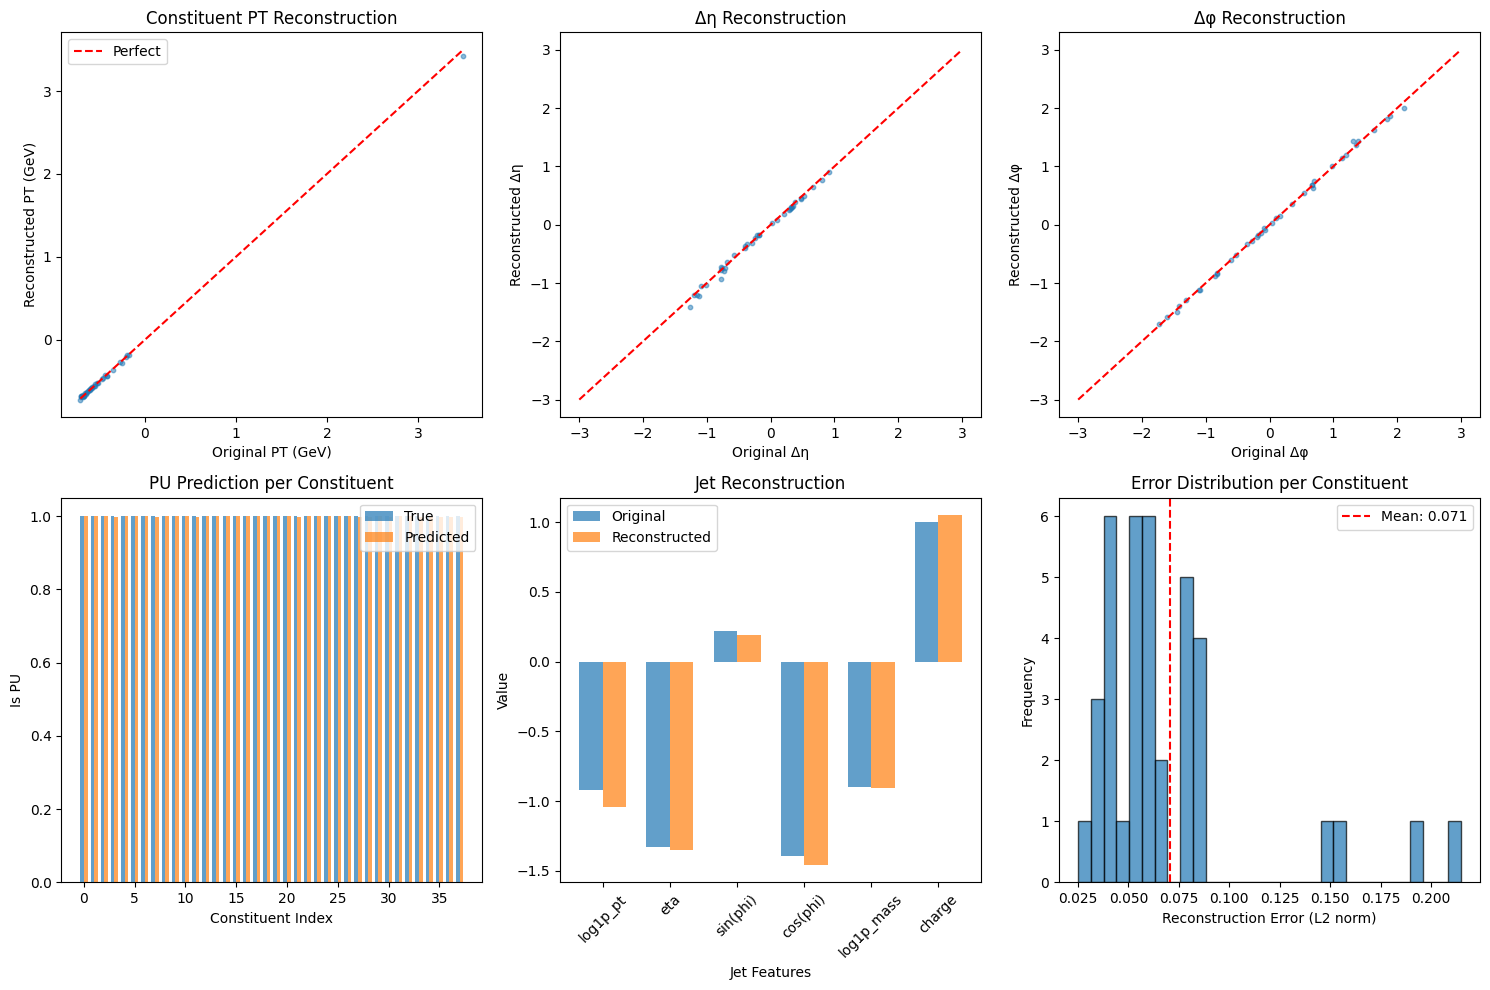


Event 0 Reconstruction Metrics:
  PF MSE: 0.000476
  Jet MSE: 0.003668
  PU Accuracy: 1.0000


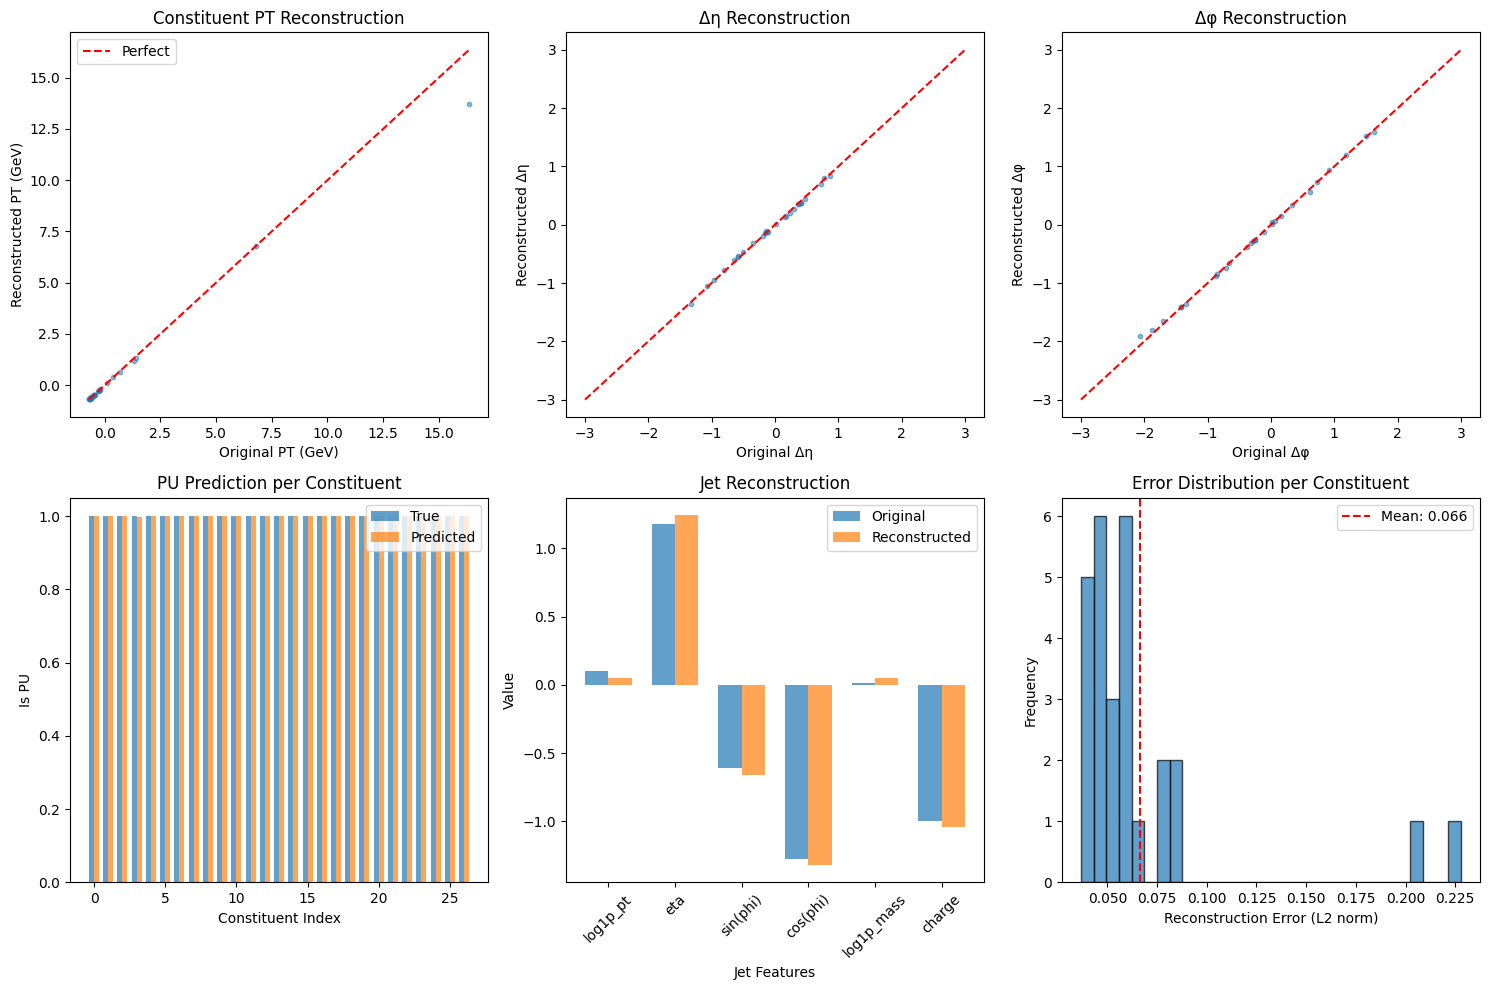


Event 0 Reconstruction Metrics:
  PF MSE: 0.000456
  Jet MSE: 0.002449
  PU Accuracy: 1.0000


In [122]:
val_iter = iter(val_loader)
for i in range(5):
    val_batch = next(val_iter)
    metrics = visualize_reconstruction(
            trained_model, val_batch,
            const_norm, jet_norm,
            const_continous_idx, jet_continous_idx,
            device='cuda'
        )

In [ ]:
# Analisi delle scale dei dati
def analyze_data_scale(loader):
    batch = next(iter(loader))
    const = batch['const']
    jet = batch['jet']
    
    print("="*50)
    print("DATA SCALE ANALYSIS")
    print("="*50)
    
    # Constituent features
    print("\nConstituent features:")
    feature_names = [
        'log1p_pt', 'delta_eta', 'delta_phi', 'charge', 'log1p_mass',
        'd0_norm', 'dz_norm', 'log1p_d0_err', 'log1p_dz_err', 'puppiW',
        'is_charged', 'is_pion', 'is_kaon', 'is_proton'
    ]
    
    for i, name in enumerate(feature_names):
        mean_val = const[:, :, i].mean().item()
        std_val = const[:, :, i].std().item()
        min_val = const[:, :, i].min().item()
        max_val = const[:, :, i].max().item()
        
        if abs(mean_val) > 1e6 or abs(std_val) > 1e6:
            print(f"  {name}: mean={mean_val:.2e}, std={std_val:.2e}, min={min_val:.2e}, max={max_val:.2e} ⚠️ SCALA ENORME!")
        else:
            print(f"  {name}: mean={mean_val:.4f}, std={std_val:.4f}, range=[{min_val:.4f}, {max_val:.4f}]")
    
    # Jet features
    print("\nJet features:")
    jet_names = ['log1p_pt', 'eta', 'sin(phi)', 'cos(phi)', 'log1p_mass', 'charge']
    for i, name in enumerate(jet_names):
        mean_val = jet[:, i].mean().item()
        std_val = jet[:, i].std().item()
        min_val = jet[:, i].min().item()
        max_val = jet[:, i].max().item()
        
        if abs(mean_val) > 1e6 or abs(std_val) > 1e6:
            print(f"  {name}: mean={mean_val:.2e}, std={std_val:.2e} ⚠️ SCALA ENORME!")
        else:
            print(f"  {name}: mean={mean_val:.4f}, std={std_val:.4f}, range=[{min_val:.4f}, {max_val:.4f}]")
    
    # Verifica se i dati sono in MeV
    pt_original = np.expm1(const[0, :, 0].cpu().numpy())
    print(f"\nPT originale (primo costituente, primo evento): {pt_original[0]:.2f} GeV")
    if pt_original[0] > 1000:
        print("⚠️ ALERT: PT > 1000 GeV! I dati potrebbero essere in MeV?")
    
    return const, jet

analyze_data_scale(loader)